In [ ]:
import pandas as pd 
import geopandas as gpd 
from bcgw2gdf import bcgw2gdf
from shapely.geometry import shape
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects
import datetime


pd.set_option('display.float_format', lambda x: '%.3f' % x)
 

In [2]:
bcgw2gdf=bcgw2gdf()
bcgw2gdf.bcgw_connect()

In [ ]:
img_out=r'projects/gr_2025_527_wolv_priority_areas/deliverables/'
thlb=r'/projects/gr_2025_527_wolv_priority_areas/source_data/thlb_clip.shp'
cpa=r'/1_InputData/06_Deliverables/11_CPA_Shapes_Merged_20240404/CPA_All_Shapes_Merged.shp'
wolv_hab=r'/GR_2024_1361_Wolverine_Data_Prep/deliverables/WolverineCaribouDraftShapefiles20240919'
he_core=fr"{wolv_hab}/WolverineCaribouHighElevationDraftPolygon20240919.shp"
le_core=fr"{wolv_hab}/WolverineCaribouLowElevationDraftPolygon20240919.shp"
matrix=fr"{wolv_hab}/WolverineCaribouMatrixDraftPolygon20240919.shp"
source_data=r"/projects/gr_2025_527_wolv_priority_areas/source_data/"
he_thlb=fr"{source_data}/he_thlb.gpkg"
le_thlb=fr"{source_data}/le_thlb.gpkg"
cpa_thlb=fr"{source_data}/cpa_thlb.gpkg"
wolv_thlb=fr"{source_data}/wolv_thlb.gpkg"

In [ ]:
#create table structure 
data = {
    "Area Description": [
        "Wolverine Range",
        "Draft High Elevation Core excluding existing “Protections”",
        "THLB",
        "Draft Low Elevation Core excluding existing “Protections”",
        "THLB",
        "Caribou Priority Area",
        "Caribou Priority Area excluding existing “Protections”",
        "CPA excluding existing “Protections” within THLB",
        "CPA intersect LE Core",
        "CPA intersect HE Core",
        "Total THLB"
    ],
    "Area (ha)": [None] * 10,         # Placeholder for now
    "PGTSA (ha)": [None] * 10,
    "Mack TSA (ha)": [None] * 10
}
# Create the DataFrame
df = pd.DataFrame(data)

In [5]:

wq = """select * from WHSE_WILDLIFE_INVENTORY.GCPB_CARIBOU_POPULATION_SP 
where HERD_NAME ='Wolverine'
"""
wolv_herd=bcgw2gdf.get_spatial_table(wq)

tsa_q=""" select * from WHSE_ADMIN_BOUNDARIES.FADM_TSA 
            where TSB_NUMBER IS NULL And RETIREMENT_DATE IS NULL and TSA_NUMBER IN (16,24)
        """
tsa=bcgw2gdf.get_spatial_table(tsa_q)

protected_areas_q="""select * from WHSE_TANTALIS.TA_PARK_ECORES_PA_SVW
                    """
protected_areas=bcgw2gdf.get_spatial_table(protected_areas_q)

In [6]:
# first row in spreadsheet
wolv_area=float(wolv_herd.area/10000)
intersections = gpd.overlay(tsa, wolv_herd, how='intersection')
intersections['area_ha'] = intersections.geometry.area / 10_000
# add to table
wolverine_rang=[wolv_area,intersections['area_ha'][0],intersections['area_ha'][1]]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], wolverine_rang):
    df.at[0, col] = val
    



/tmp/ipykernel_1891/2519598828.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  wolv_area=float(wolv_herd.area/10000)


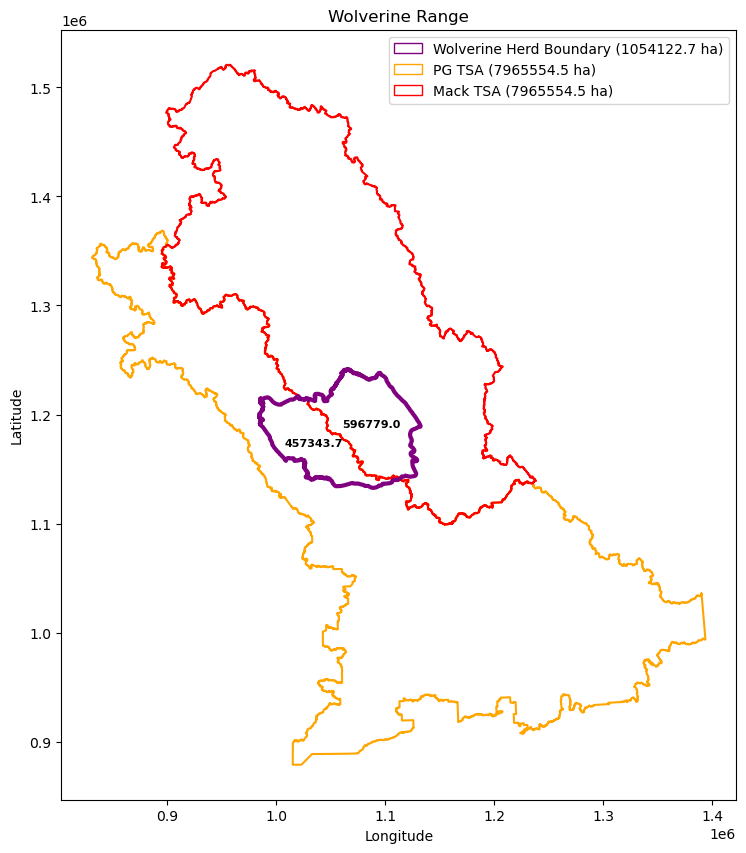

In [7]:
#plot and export
pg_ha=round(tsa["FEATURE_AREA_SQM"][0]/10_000,1)
mk_ha=round(tsa["FEATURE_AREA_SQM"][0]/10_000,1)


minx, miny, maxx, maxy =tsa.total_bounds
padding = 0.05
dx = (maxx - minx) * padding
dy = (maxy - miny) * padding

fig, ax = plt.subplots(figsize=(10, 10))



tsa_colors=['orange','red']

tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)
intersections.plot(ax=ax, color='none', edgecolor='none')
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)

# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)")
]
ax.legend(handles=legend_elements)

for idx, row in intersections.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, round(row['area_ha'],1),
            fontsize=8, ha='center', va='center', color='black', weight='bold')

# Add title and labels
plt.title("Wolverine Range")
plt.xlabel("Longitude")
plt.ylabel("Latitude")




# Show the plot
plt.show()
plot_image_path=f"{img_out}/1_wolverine_range.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [8]:
he=gpd.read_file(he_core)
he_diss=he.dissolve()
he_remove=he_diss.overlay(protected_areas, how='difference')
#2nd row in spreadsheet

he_area=float(he_remove.area/ 10_000) 
intersections = gpd.overlay(tsa, he_remove, how='intersection')
intersections['area_ha'] = intersections.geometry.area / 10_000
# add to table
he_col=[he_area,intersections['area_ha'][0],intersections['area_ha'][1]]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], he_col):
    df.at[1, col] = val

/tmp/ipykernel_1397/2165250049.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  he_area=float(he_remove.area/ 10_000)


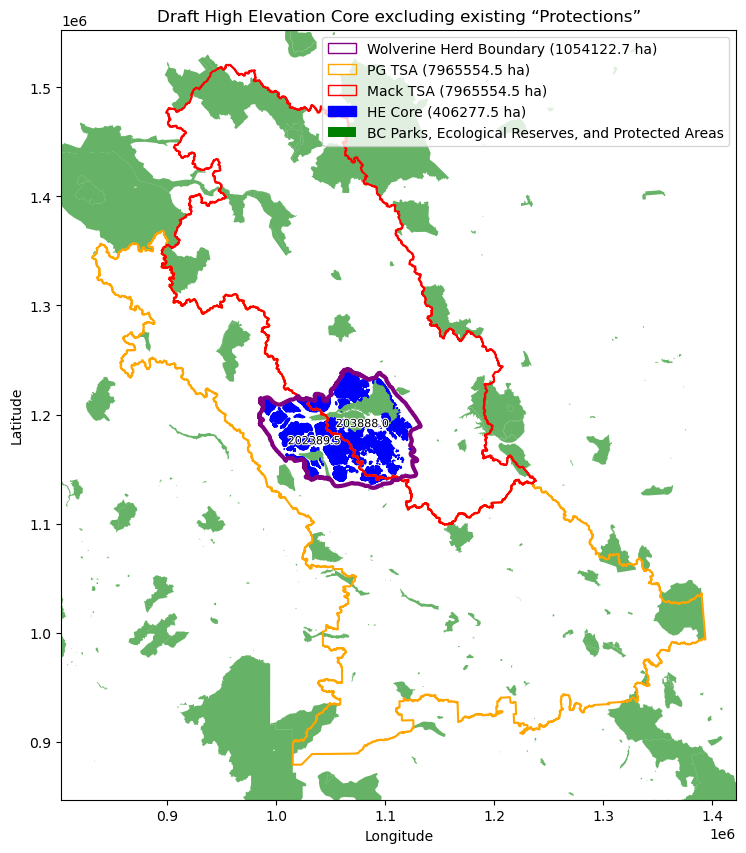

In [9]:
#plot and export 


fig, ax = plt.subplots(figsize=(10, 10))

protected_areas.plot(ax=ax,color='green', alpha=0.6 )

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)
tsa_colors=['orange','red']

intersections.plot(ax=ax, color='blue', edgecolor='blue',linewidth=1),
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)

# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='blue', edgecolor='blue', label=f"HE Core ({round(he_area,1)} ha)"),
    Patch(facecolor='green', label=f"BC Parks, Ecological Reserves, and Protected Areas")
]
ax.legend(handles=legend_elements)

for idx, row in intersections.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title('Draft High Elevation Core excluding existing “Protections”')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/2_high_elevation_core_excluding_protections.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [10]:
le=gpd.read_file(le_core)
le_diss=le.dissolve()
#4nd row in spreadsheet
le_remove=le_diss.overlay(protected_areas, how='difference')

le_area=float(le_remove.area/10000)
intersections = gpd.overlay(tsa, le_remove, how='intersection')
intersections['area_ha'] = intersections.geometry.area / 10_000
# add to table
le_col=[le_area,intersections['area_ha'][0],intersections['area_ha'][1]]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], le_col):
    df.at[3, col] = val

/tmp/ipykernel_1397/3233560358.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  le_area=float(le_remove.area/10000)


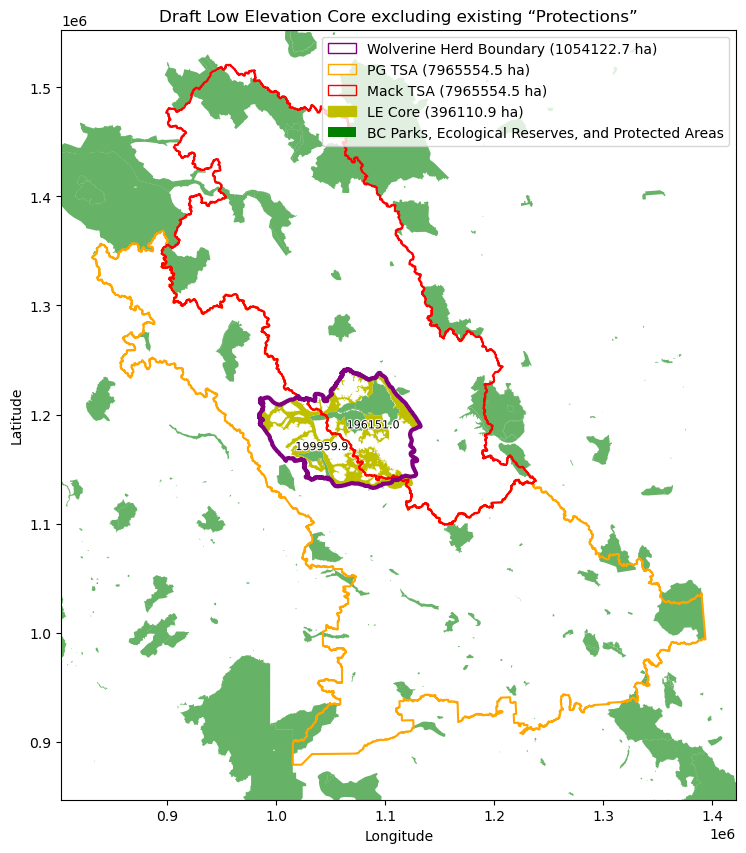

In [11]:
#plot and export 
fig, ax = plt.subplots(figsize=(10, 10))

protected_areas.plot(ax=ax,color='green', alpha=0.6 )

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

tsa_colors=['orange','red']

intersections.plot(ax=ax, color='y', linewidth=1),
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)

# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='y', edgecolor='y', label=f"LE Core ({round(le_area,1)} ha)"),
    Patch(facecolor='green', label=f"BC Parks, Ecological Reserves, and Protected Areas")
]
ax.legend(handles=legend_elements)

for idx, row in intersections.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title('Draft Low Elevation Core excluding existing “Protections”')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/4_low_elevation_core_excluding_protections.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [12]:
cpa_gdf=gpd.read_file(cpa)

#if cpa needs to be intersected with wolv boundary 
cpa_gdf=gpd.overlay(wolv_herd, cpa_gdf, how='intersection')
#6th row in spreadsheet
wolv_gdf_diss=wolv_gdf.dissolve()
wolv_area=float(wolv_gdf_diss.area/10000)
intersections = gpd.overlay(tsa, cpa_gdf, how='intersection')
intersections['area_ha'] = intersections.geometry.area / 10_000
# add to table
cpa_col=[cpa_area,intersections['area_ha'][0],intersections['area_ha'][1]]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], cpa_col):
    df.at[5, col] = val

/tmp/ipykernel_1397/1331845260.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpa_area=float(cpa_gdf_diss.area/10000)


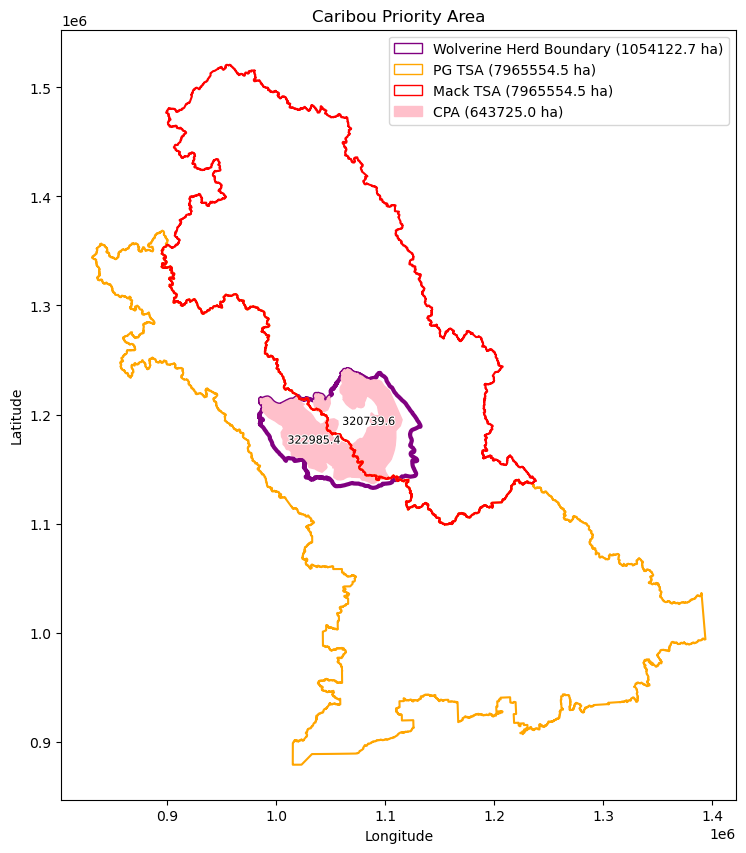

In [13]:
#plot and export 
fig, ax = plt.subplots(figsize=(10, 10))



tsa_colors=['orange','red']
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='pink', edgecolor='pink', label=f"CPA ({round(cpa_area,1)} ha)")
]
ax.legend(handles=legend_elements)

for idx, row in intersections.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title("Caribou Priority Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/6_caribou_priority_area.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [14]:
#7th row in spreadsheet
cpa_remove=cpa_gdf_diss.overlay(protected_areas, how='difference')
# cpa_gdf=cpa_remove.dissolve()
cpa_area_rm=float(cpa_remove.area/10000)
intersections = gpd.overlay(tsa, cpa_remove, how='intersection')
intersections['area_ha'] = intersections.geometry.area / 10_000
# add to table
cpa_col=[cpa_area_rm,intersections['area_ha'][0],intersections['area_ha'][1]]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], cpa_col):
    df.at[6, col] = val

/tmp/ipykernel_1397/1040628411.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpa_area_rm=float(cpa_remove.area/10000)


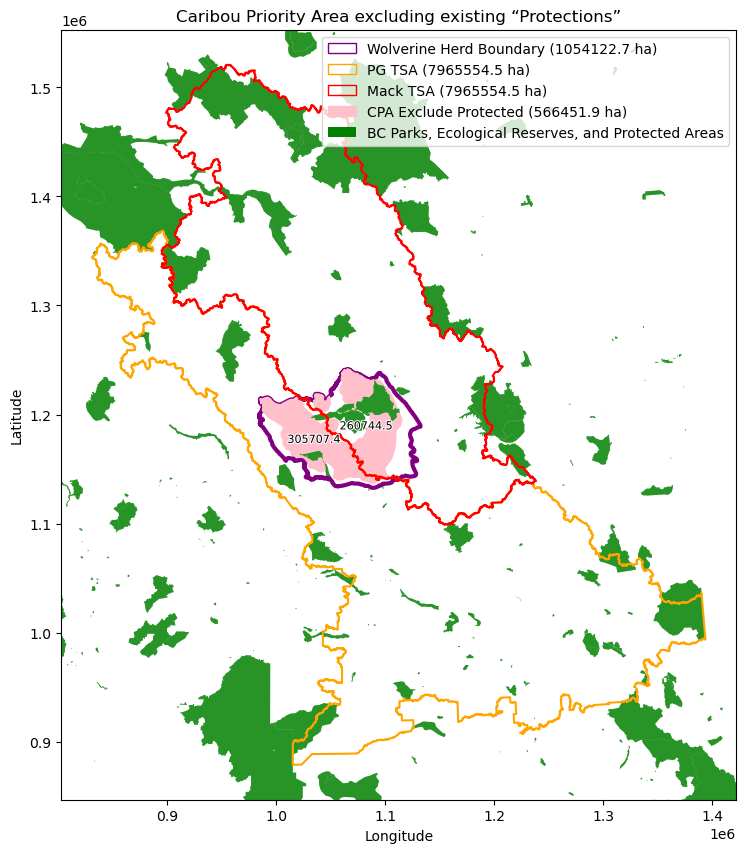

In [15]:
#plot and export 
fig, ax = plt.subplots(figsize=(10, 10))

protected_areas.plot(ax=ax,color='green', alpha=0.6 )

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

tsa_colors=['orange','red']
protected_areas.plot(ax=ax,color='green', alpha=0.6 )
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='pink', edgecolor='pink', label=f"CPA Exclude Protected ({round(cpa_area_rm,1)} ha)"),
    Patch(facecolor='green', label=f"BC Parks, Ecological Reserves, and Protected Areas")
]
ax.legend(handles=legend_elements)

for idx, row in intersections.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title('Caribou Priority Area excluding existing “Protections”')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/7_cps_excluding_protections”.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [16]:
le_cpa=gpd.overlay(cpa_gdf_diss,le_diss)

le_cpa_area=float(le_cpa.area/10000)
intersections = gpd.overlay(tsa, le_cpa, how='intersection')
intersections['area_ha'] = intersections.geometry.area / 10_000
# add to table
cpa_col=[le_cpa_area,intersections['area_ha'][0],intersections['area_ha'][1]]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], cpa_col):
    df.at[8, col] = val

/tmp/ipykernel_1397/2920220479.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  le_cpa_area=float(le_cpa.area/10000)


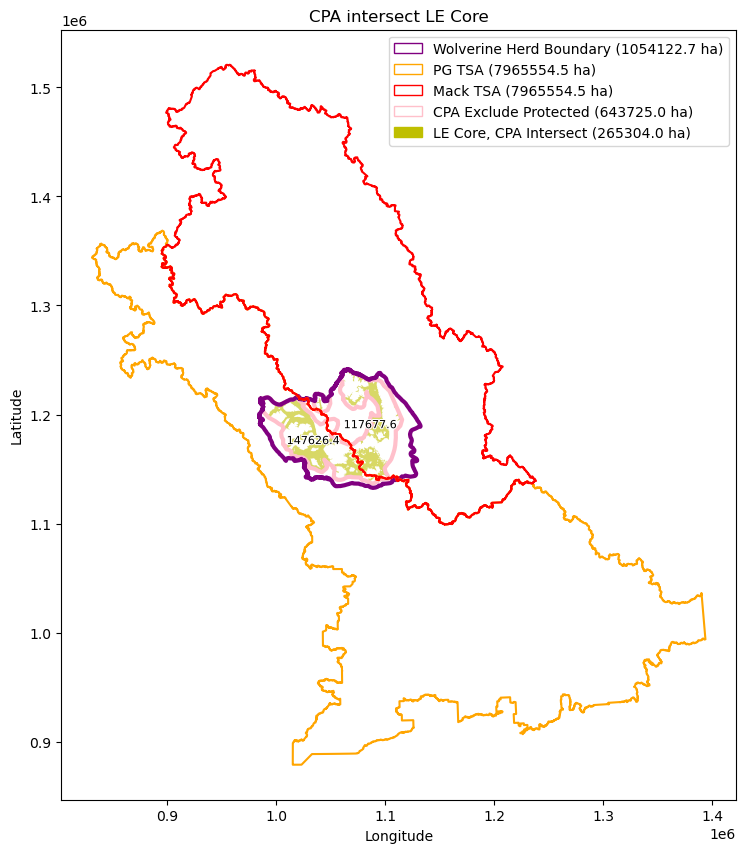

In [17]:
#plot and export 
fig, ax = plt.subplots(figsize=(10, 10))


tsa_colors=['orange','red']

le_cpa.plot(ax=ax,color='y', alpha=0.6)
# le.plot(ax=ax, edgecolor='black', facecolor='none',linewidth=1.5)
cpa_gdf.plot(ax=ax, edgecolor='pink', facecolor='none',linewidth=3)
# protected_areas.plot(ax=ax,color='green', alpha=0.6 )
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
# intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='none', edgecolor='pink', label=f"CPA Exclude Protected ({round(cpa_area,1)} ha)"),
    Patch(facecolor='y', edgecolor='y', label=f"LE Core, CPA Intersect ({round(le_cpa_area,1)} ha)")
]
ax.legend(handles=legend_elements)

for idx, row in intersections.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title("CPA intersect LE Core")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/9_cpa_intersect_le_core.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [18]:
he_cpa=gpd.overlay(cpa_gdf_diss,he_diss)

he_cpa_area=float(he_cpa.area/10000)
intersections = gpd.overlay(tsa, he_cpa, how='intersection')
intersections['area_ha'] = intersections.geometry.area / 10_000
# add to table
cpa_col=[he_cpa_area,intersections['area_ha'][0],intersections['area_ha'][1]]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], cpa_col):
    df.at[9, col] = val

/tmp/ipykernel_1397/362400304.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  he_cpa_area=float(he_cpa.area/10000)


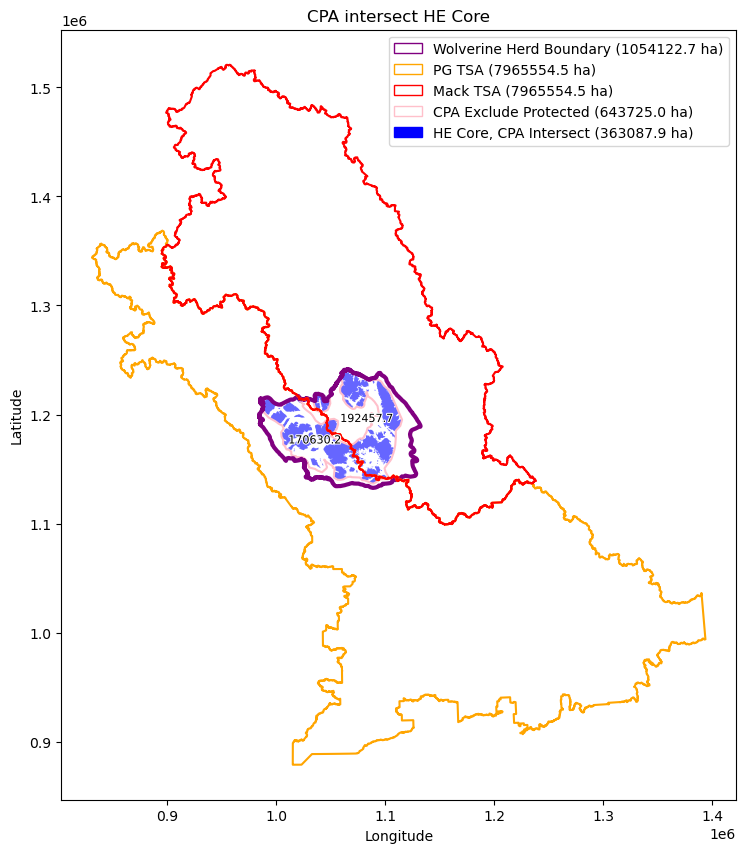

In [19]:
#plot and export 
fig, ax = plt.subplots(figsize=(10, 10))


tsa_colors=['orange','red']

he_cpa.plot(ax=ax,color='blue', alpha=0.6)
# le.plot(ax=ax, edgecolor='black', facecolor='none',linewidth=1.5)
cpa_gdf.plot(ax=ax, edgecolor='pink', facecolor='none',linewidth=1.5)
# protected_areas.plot(ax=ax,color='green', alpha=0.6 )
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
# intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='none', edgecolor='pink', label=f"CPA Exclude Protected ({round(cpa_area,1)} ha)"),
    Patch(facecolor='blue', edgecolor='blue', label=f"HE Core, CPA Intersect ({round(he_cpa_area,1)} ha)")
]
ax.legend(handles=legend_elements)

for idx, row in intersections.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title("CPA intersect HE Core")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/10_cpa_intersect_he_core.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [20]:
df

,Area Description,Area (ha),PGTSA (ha),Mack TSA (ha)
0,Wolverine Range,1054122.676,457343.729,596778.950
1,Draft High Elevation Core excluding existing “...,406277.482,202389.491,203887.993
2,THLB,None,None,None
3,Draft Low Elevation Core excluding existing “P...,396110.930,199959.900,196151.031
4,THLB,None,None,None
5,Caribou Priority Area,643724.996,322985.422,320739.575
6,Caribou Priority Area excluding existing “Prot...,566451.877,305707.387,260744.491
7,CPA excluding existing “Protections” within THLB,None,None,None
8,CPA intersect LE Core,265303.970,147626.372,117677.599
9,CPA intersect HE Core,363087.931,170630.244,192457.689


In [21]:
he_remove.to_file(f"{img_out}/he_remove.shp")
le_remove.to_file(f"{img_out}/le_remove.shp")
cpa_remove.to_file(f"{img_out}/cpa_remove.shp")

/tmp/ipykernel_1397/3365429463.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  cpa_remove.to_file(f"{img_out}/cpa_remove.shp")


In [22]:
he_thlb_gdf=gpd.read_file(he_thlb,layer='clipped' )

In [23]:
he_thlb_gdf=gpd.read_file(he_thlb,layer='clipped')
he_thlb_gdf['new_thlb_ha']=he_thlb_gdf['thlb_fact']*(he_thlb_gdf.area/10000)
he_thlb_gdf_area=he_thlb_gdf['new_thlb_ha'].sum()
#3rd row in spreadsheet

# he_thlb_area=float(he_remove.area/ 10_000) 
intersections = gpd.overlay(tsa, he_thlb_gdf, how='intersection')
intersections['area_ha'] = he_thlb_gdf['thlb_fact']*(intersections.geometry.area / 10_000)
tsa_24 = intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'Prince George TSA']
tsa_24_area=tsa_24['area_ha'].sum()
tsa_16=intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'MacKenzie TSA']
tsa_16_area=tsa_16['area_ha'].sum()
he_col=[round(he_thlb_gdf_area,2),round(tsa_24_area,2),round(tsa_16_area,2)]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], he_col):
    df.at[2, col] = val

he_thlb_diss=he_thlb_gdf.dissolve(by=['tsa_number'])
he_thlb_diss['thlb_area_ha']=[tsa_16_area,tsa_24_area]

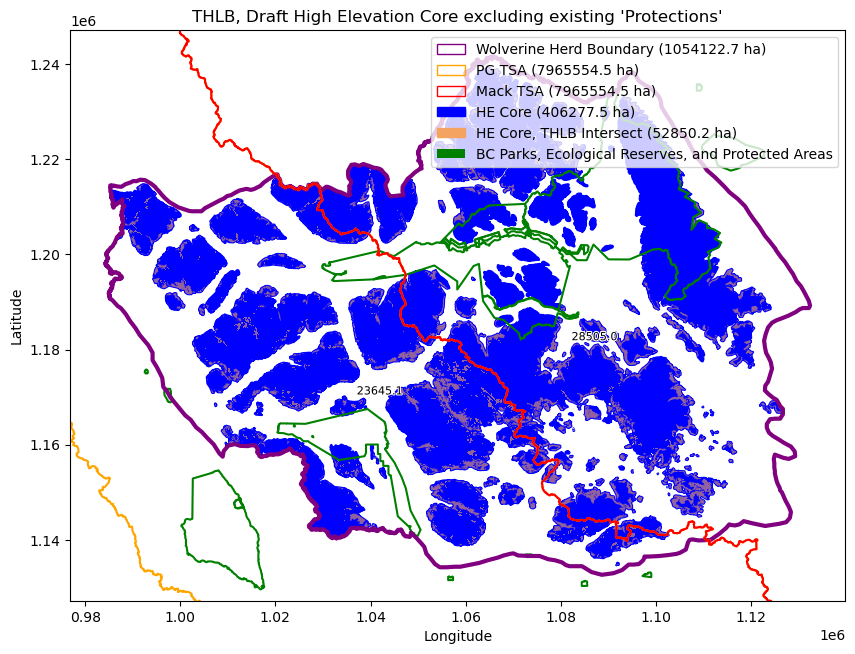

In [24]:
#plot and export 

minx, miny, maxx, maxy =wolv_herd.total_bounds
padding = 0.05
dx = (maxx - minx) * padding
dy = (maxy - miny) * padding

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

tsa_colors=['orange','red']


he_diss.plot(ax=ax, edgecolor='blue', facecolor='blue',linewidth=1.5)
he_thlb_diss.plot(ax=ax,color='sandybrown', alpha=0.6)
protected_areas.plot(ax=ax, edgecolor='green', facecolor='none', linewidth=1.5)
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
# intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='blue', edgecolor='blue', label=f"HE Core ({round(he_area,1)} ha)"),
    Patch(facecolor='sandybrown', edgecolor='sandybrown', label=f"HE Core, THLB Intersect ({round(he_thlb_gdf_area,1)} ha)"),
    Patch(facecolor='green', label=f"BC Parks, Ecological Reserves, and Protected Areas")
]
ax.legend(handles=legend_elements)

for idx, row in he_thlb_diss.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['thlb_area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title("THLB, Draft High Elevation Core excluding existing 'Protections'")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/3_thlb_core.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [25]:
le_thlb_gdf=gpd.read_file(le_thlb,layer='clipped')
le_thlb_gdf['new_thlb_ha']=le_thlb_gdf['thlb_fact']*(le_thlb_gdf.area/10000)
le_thlb_gdf_area=le_thlb_gdf['new_thlb_ha'].sum()
#3rd row in spreadsheet

# he_thlb_area=float(he_remove.area/ 10_000) 
intersections = gpd.overlay(tsa, le_thlb_gdf, how='intersection')
intersections['area_ha'] = le_thlb_gdf['thlb_fact']*(intersections.geometry.area / 10_000)
tsa_24 = intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'Prince George TSA']
tsa_24_area=tsa_24['area_ha'].sum()
tsa_16=intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'MacKenzie TSA']
tsa_16_area=tsa_16['area_ha'].sum()
he_col=[round(le_thlb_gdf_area,2),round(tsa_24_area,2),round(tsa_16_area,2)]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], he_col):
    df.at[4, col] = val

le_thlb_diss=intersections.dissolve(by=['tsa_number'])
le_thlb_diss['thlb_area_ha']=[tsa_16_area,tsa_24_area]

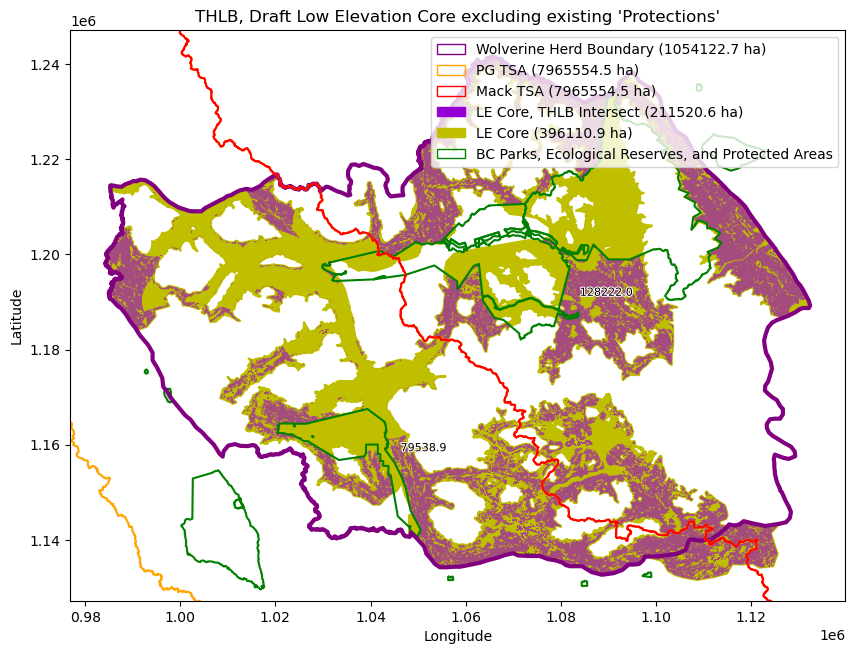

In [26]:
#plot and export 

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

tsa_colors=['orange','red']
le_diss.plot(ax=ax, edgecolor='y', facecolor='y',linewidth=1.5)
le_thlb_diss.plot(ax=ax,color='darkviolet', alpha=0.6)
# le.plot(ax=ax, edgecolor='black', facecolor='none',linewidth=1.5)
protected_areas.plot(ax=ax, edgecolor='green', facecolor='none',linewidth=1.5)
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
# intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='darkviolet', edgecolor='darkviolet', label=f"LE Core, THLB Intersect ({round(le_thlb_gdf_area,1)} ha)"),
    Patch(facecolor='y', edgecolor='y', label=f"LE Core ({round(le_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='green', label=f"BC Parks, Ecological Reserves, and Protected Areas")
]
ax.legend(handles=legend_elements)

for idx, row in le_thlb_diss.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['thlb_area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title("THLB, Draft Low Elevation Core excluding existing 'Protections'")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/5_le_thlb_core.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [30]:
cpa_thlb_gdf=gpd.read_file(cpa_thlb,layer='clipped')
cpa_thlb_gdf=gpd.overlay(cpa_gdf, cpa_thlb_gdf, how='intersection')
cpa_thlb_gdf['new_thlb_ha']=cpa_thlb_gdf['thlb_fact']*(cpa_thlb_gdf.area/10000)
cpa_thlb_gdf_area=cpa_thlb_gdf['new_thlb_ha'].sum()
#3rd row in spreadsheet

# he_thlb_area=float(he_remove.area/ 10_000) 
intersections = gpd.overlay(tsa, cpa_thlb_gdf, how='intersection')
intersections['area_ha'] = cpa_thlb_gdf['thlb_fact']*(intersections.geometry.area / 10_000)
tsa_24 = intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'Prince George TSA']
tsa_24_area=tsa_24['area_ha'].sum()
tsa_16=intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'MacKenzie TSA']
tsa_16_area=tsa_16['area_ha'].sum()
he_col=[round(cpa_thlb_gdf_area,2),round(tsa_24_area,2),round(tsa_16_area,2)]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], he_col):
    df.at[7, col] = val

cpa_thlb_diss=cpa_thlb_gdf.dissolve(by=['tsa_number'])
cpa_thlb_diss['thlb_area_ha']=[tsa_16_area,tsa_24_area]

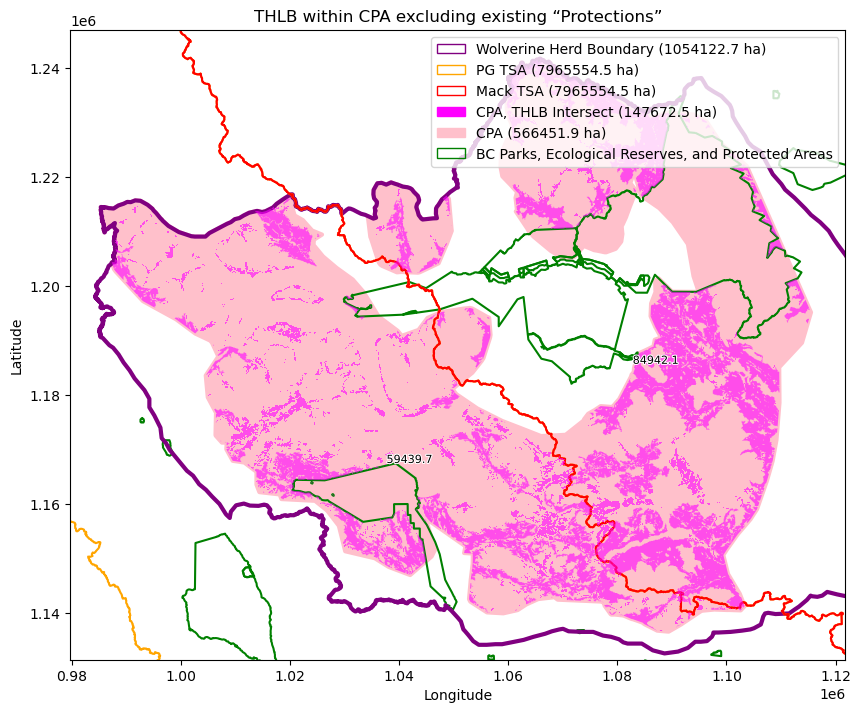

In [31]:
#plot and export 
minx, miny, maxx, maxy =cpa_thlb_diss.total_bounds
padding = 0.05
dx = (maxx - minx) * padding
dy = (maxy - miny) * padding

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

tsa_colors=['orange','red']
cpa_gdf.plot(ax=ax, edgecolor='pink', facecolor='pink',linewidth=3)

# le.plot(ax=ax, edgecolor='black', facecolor='none',linewidth=1.5)
protected_areas.plot(ax=ax, edgecolor='green', facecolor='none', linewidth=1.5)
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
# intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)
cpa_thlb_diss.plot(ax=ax,color='magenta', alpha=0.6)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='magenta', edgecolor='magenta', label=f"CPA, THLB Intersect ({round(cpa_thlb_gdf_area,1)} ha)"),
    Patch(facecolor='pink', edgecolor='pink', label=f"CPA ({round(cpa_area_rm,1)} ha)"),
    Patch(facecolor='none',edgecolor='green', label=f"BC Parks, Ecological Reserves, and Protected Areas")
]
ax.legend(handles=legend_elements)

for idx, row in cpa_thlb_diss.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['thlb_area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title("THLB within CPA excluding existing “Protections”")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/8_thlb_in_cpa.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
wolv_thlb_gdf=gpd.read_file(wolv_thlb,layer='Merged')

In [ ]:


wolv_thlb_gdf['new_thlb_ha']=wolv_thlb_gdf['thlb_fact']*(wolv_thlb_gdf.area/10000)
wolv_thlb_gdf_area=wolv_thlb_gdf['new_thlb_ha'].sum()
#3rd row in spreadsheet

# he_thlb_area=float(he_remove.area/ 10_000) 
intersections = gpd.overlay(tsa, wolv_thlb_gdf, how='intersection')
intersections['area_ha'] = wolv_thlb_gdf['thlb_fact']*(intersections.geometry.area / 10_000)
tsa_24 = intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'Prince George TSA']
tsa_24_area=tsa_24['area_ha'].sum()
tsa_16=intersections[intersections['TSA_NUMBER_DESCRIPTION'] == 'MacKenzie TSA']
tsa_16_area=tsa_16['area_ha'].sum()
he_col=[round(wolv_thlb_gdf_area,2),round(tsa_24_area,2),round(tsa_16_area,2)]
for col, val in zip(["Area (ha)", "PGTSA (ha)", "Mack TSA (ha)"], he_col):
    df.at[10, col] = val

wolv_thlb_diss=wolv_thlb_gdf.dissolve(by=['tsa_number'])
wolv_thlb_diss['thlb_area_ha']=[tsa_16_area,tsa_24_area]

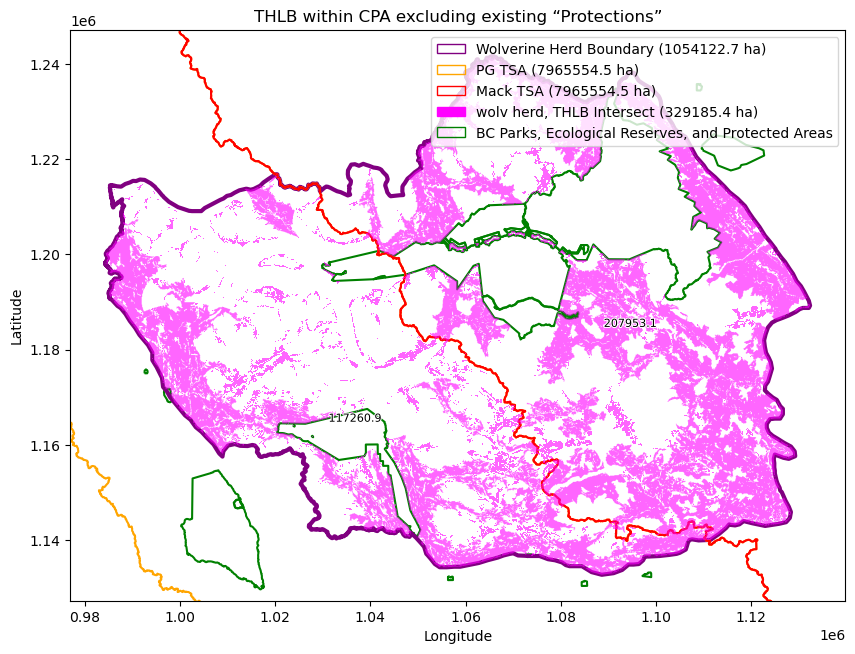

In [13]:
#plot and export 
minx, miny, maxx, maxy =wolv_thlb_diss.total_bounds
padding = 0.05
dx = (maxx - minx) * padding
dy = (maxy - miny) * padding

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)

tsa_colors=['orange','red']

# le.plot(ax=ax, edgecolor='black', facecolor='none',linewidth=1.5)
protected_areas.plot(ax=ax, edgecolor='green', facecolor='none', linewidth=1.5)
wolv_herd.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=3)
# intersections.plot(ax=ax, color='pink', edgecolor='pink',linewidth=1)
tsa.plot(ax=ax, edgecolor=tsa_colors, facecolor='none', linewidth=1.5)
wolv_thlb_diss.plot(ax=ax,color='magenta', alpha=0.6)


# Add custom legend
legend_elements = [
    Patch(facecolor='none', edgecolor='purple', label=f"Wolverine Herd Boundary ({round(wolv_area,1)} ha)"),
    Patch(facecolor='none', edgecolor='orange', label=f"PG TSA ({pg_ha} ha)"),
    Patch(facecolor='none', edgecolor='red', label=f"Mack TSA ({mk_ha} ha)"),
    Patch(facecolor='magenta', edgecolor='magenta', label=f"wolv herd, THLB Intersect ({round(wolv_thlb_gdf_area,1)} ha)"),
    # Patch(facecolor='pink', edgecolor='pink', label=f"CPA ({round(cpa_area_rm,1)} ha)"),
    Patch(facecolor='none',edgecolor='green', label=f"BC Parks, Ecological Reserves, and Protected Areas")
]
ax.legend(handles=legend_elements)

for idx, row in wolv_thlb_diss.iterrows():
    centroid = row.geometry.centroid
    text=ax.text(centroid.x, centroid.y, round(row['thlb_area_ha'],1),
            fontsize=8, ha='center', va='center', color='black')
    text.set_path_effects([
        path_effects.Stroke(linewidth=1.5, foreground='white'),
        path_effects.Normal()
    ])

# Add title and labels
plt.title("THLB within CPA excluding existing “Protections”")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()
plot_image_path=f"{img_out}/8_thlb_in_cpa.png"
plt.savefig(plot_image_path, dpi=300, bbox_inches='tight')
plt.close()

In [14]:
print(f"wolv thlb {wolv_thlb_gdf_area}ha")
print(f"tsa 24 thlb {tsa_24_area}")
print(f"tsa 16 thlb {tsa_16_area}")

wolv thlb 329185.40699446143ha
tsa 24 thlb 117260.87088916992
tsa 16 thlb 207953.10001863164


In [32]:
df.to_excel(f"{img_out}/wolverine_cpa_20250409.xlsx",sheet_name='Wolverine', engine='xlsxwriter')